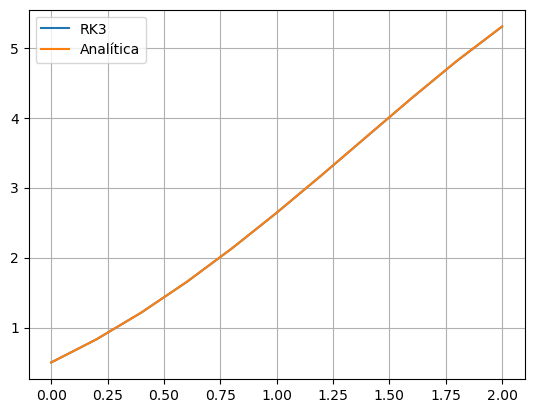

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def rk(params, f, yo, t0, tf, h):
    C2 = params["C2"]
    C3 = params["C3"]
    A21 = params["A21"]
    A31 = params["A31"] 
    A32 = params["A32"]
    B1 = params["B1"]
    B2 = params["B2"]
    B3 = params["B3"]
    N = int((tf - t0) / h)
    Y = np.array([])
    T = np.array([])
    Y = np.append(Y, yo)
    T = np.append(T, t0)
    for i in range(N):
        k1 = f(T[i], Y[i])
        k2 = f(T[i] + h * C2, Y[i] + h * k1 * A21)
        k3 = f(T[i] + h * C3, Y[i] + h * k1 * A31 + h * k2 * A32)
        Y = np.append(Y, Y[i] + h * (k1 * B1 + k2 * B2 + k3 * B3))
        T = np.append(T, T[i] + h)
    return T, Y

def f(t, y):
    return y - t**2 + 1

def analitica(t):
    return (t + 1)**2 - 0.5 * np.exp(t)

params = {"C2": 0.5, "C3": 1.0, "A21": 0.5, "A31": -1.0, "A32": 2.0, "B1": 1/6, "B2": 4/6, "B3": 1/6}
yo = 0.5
t0 = 0.0
tf = 2.0
h = 0.2
T, Y = rk(params, f, yo, t0, tf, h)
Y_analitica = analitica(T)
plt.plot(T, Y, label='RK3')
plt.plot(T, Y_analitica, label='Analítica')
plt.legend()
plt.grid(True)
plt.show()



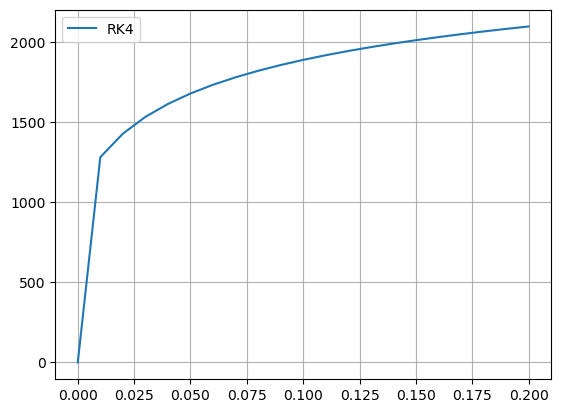

Valor final de x: 2098.8339337669827


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def rk4(params, f, yo, t0, tf, h):
    C2 = params["C2"]
    C3 = params["C3"]
    C4 = params["C4"]
    A21 = params["A21"]
    A31 = params["A31"] 
    A32 = params["A32"]
    A41 = params["A41"]
    A42 = params["A42"]
    A43 = params["A43"]
    B1 = params["B1"]
    B2 = params["B2"]
    B3 = params["B3"]
    B4 = params["B4"]
    N = int((tf - t0) / h)
    Y = np.array([])
    T = np.array([])
    Y = np.append(Y, yo)
    T = np.append(T, t0)
    for i in range(N):
        k1 = f(T[i], Y[i])
        k2 = f(T[i] + h * C2, Y[i] + h * k1 * A21)
        k3 = f(T[i] + h * C3, Y[i] + h * k1 * A31 + h * k2 * A32)
        k4 = f(T[i] + h * C4, Y[i] + h * k1 * A41 + h * k2 * A42 + h * k3 * A43)
        Y = np.append(Y, Y[i] + h * (k1 * B1 + k2 * B2 + k3 * B3 + k4 * B4))
        T = np.append(T, T[i] + h)
    return T, Y

def f(t, x):
    return k * ((n1 - c1 * x)**2)*((n2 - c2 * x)**2)*((n3 - c3 * x)**3)

params_ = {"C2": 0.5, "C3": 0.5, "C4": 1.0, "A21": 0.5, "A31": 0, "A32": 0.5, "A41": 0, "A42": 0, "A43": 1.0, "B1": 1/6, "B2": 1/3, "B3": 1/3, "B4": 1/6}

k = 6.22e-19
n1 = 2e3
c1 = 2/4
n2 = 2e3
c2 = 2/4
n3 = 3e3
c3 = 3/4


y0 = 0
t0 = 0.0
tf = 0.2
h = 0.01
T, Y = rk4(params_, f, y0, t0, tf, h)
plt.plot(T, Y, label='RK4')
plt.legend()
plt.grid(True)
plt.show()

print("Valor final de x:", Y[-1])



C:\Users\equipo 10\AppData\Local\Temp\ipykernel_9280\2801290495.py:33: RuntimeWarning: overflow encountered in scalar multiply
  return k * ((n1 - c1 * x)**2)*((n2 - c2 * x)**2)*((n3 - c3 * x)**3)
C:\Users\equipo 10\AppData\Local\Temp\ipykernel_9280\255781122.py:22: RuntimeWarning: invalid value encountered in scalar add
  Y = np.append(Y, Y[i] + h * (k1 * B1 + k2 * B2 + k3 * B3))
C:\Users\equipo 10\AppData\Local\Temp\ipykernel_9280\2801290495.py:25: RuntimeWarning: invalid value encountered in scalar add
  k2 = f(T[i] + h * C2, Y[i] + h * k1 * A21)
C:\Users\equipo 10\AppData\Local\Temp\ipykernel_9280\2801290495.py:26: RuntimeWarning: invalid value encountered in scalar multiply
  k3 = f(T[i] + h * C3, Y[i] + h * k1 * A31 + h * k2 * A32)
C:\Users\equipo 10\AppData\Local\Temp\ipykernel_9280\2801290495.py:27: RuntimeWarning: invalid value encountered in scalar multiply
  k4 = f(T[i] + h * C4, Y[i] + h * k1 * A41 + h * k2 * A42 + h * k3 * A43)
C:\Users\equipo 10\AppData\Local\Temp\ipykern

Errores RK3: [nan, nan, nan, nan, nan, nan]
Errores RK4: [nan, nan, nan, nan, nan, 2121.9797866030995]


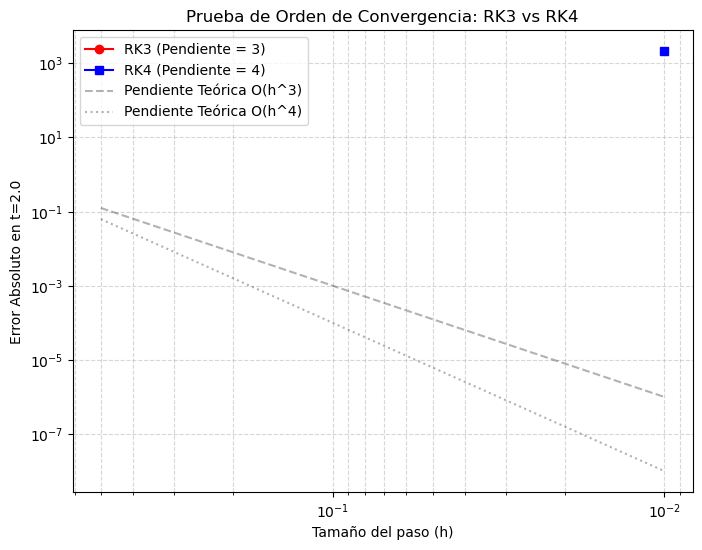

In [5]:
# Probamos con diferentes tamaños de paso h
pasos_h = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]
errores_rk3 = []
errores_rk4 = []

y_true = analitica(tf)

for h in pasos_h:
    i = 0
    _, res_rk3 = rk(params, f, y0, t0, tf, h)
    _, res_rk4 = rk4(params_, f, y0, t0, tf, h)

    errores_rk3.append(abs(y_true - res_rk3[-1]))
    errores_rk4.append(abs(y_true - res_rk4[-1]))

plt.figure(figsize=(8, 6))

print("Errores RK3:", errores_rk3)
print("Errores RK4:", errores_rk4)

plt.loglog(pasos_h, errores_rk3, 'ro-', label='RK3 (Pendiente = 3)')
plt.loglog(pasos_h, errores_rk4, 'bs-', label='RK4 (Pendiente = 4)')

plt.loglog(pasos_h, [h**3 for h in pasos_h], 'k--', alpha=0.3, label='Pendiente Teórica O(h^3)')
plt.loglog(pasos_h, [h**4 for h in pasos_h], 'k:', alpha=0.3, label='Pendiente Teórica O(h^4)')

plt.xlabel('Tamaño del paso (h)')
plt.ylabel('Error Absoluto en t=2.0')
plt.title('Prueba de Orden de Convergencia: RK3 vs RK4')

plt.gca().invert_xaxis()  # Para ver cómo el error baja al achicar h

plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)

plt.show()